In [1]:
# imports

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

SEED = 38

torch.manual_seed(SEED)

Training Dataset
torch.Size([10, 3, 224, 224])
torch.Size([10, 1, 224, 224])
tensor(1.)


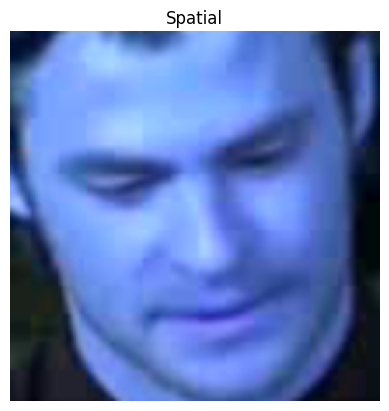

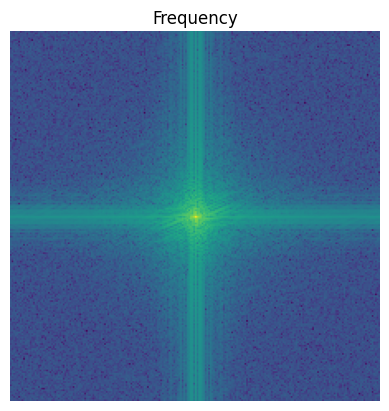

In [2]:
def add_noise(x):
    if torch.rand(1) < 0.3:
        noise = torch.randn_like(x) * 0.05
        x = torch.clamp(x + noise, 0, 1)
    return x

class DeepfakeDataset(Dataset):
    
    def __init__(self, folder, mode = "train"):
        self.files = sorted(Path(folder).glob("*.pt"))
        self.mode = mode
        self.transform = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.GaussianBlur(kernel_size=5, sigma=(0.1, 0.2)),
            T.ColorJitter(brightness=0.2, contrast=0.2)
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx])

        spatial = data["spatial"].float()
        frequency = data["frequency"].float()
        label = data["label"].float()

        if self.mode == "train":
            spatial = torch.stack([add_noise(self.transform(f)) for f in spatial])

        return {
            "spatial": spatial,
            "frequency": frequency,
            "label": label
        }

train_dataset = DeepfakeDataset("preprocessed/train", mode="train")

sample = train_dataset[0]

print("Training Dataset")
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])

plt.imshow(sample["spatial"][0].permute(1, 2, 0))
plt.title("Spatial")
plt.axis("off")
plt.show()

plt.imshow(sample["frequency"][0][0])
plt.title("Frequency")
plt.axis("off")
plt.show()

In [3]:
print("Validation Dataset")
val_dataset = DeepfakeDataset("preprocessed/val", mode="val")
sample = val_dataset[0]
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])
print("\n\nTest Dataset")
test_dataset = DeepfakeDataset("preprocessed/test", mode="test")
sample = test_dataset[0]
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])

Validation Dataset
torch.Size([10, 3, 224, 224])
torch.Size([10, 1, 224, 224])
tensor(1.)


Test Dataset
torch.Size([10, 3, 224, 224])
torch.Size([10, 1, 224, 224])
tensor(1.)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [5]:
class Model0(nn.Module):
    def __init__(self):
        super().__init__()

        self.spatial_net = models.mobilenet_v2(weights="IMAGENET1K_V1").features

        for param in self.spatial_net.parameters():
            param.required_grad = False
            
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        self.freq_net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(8, 16, 3, padding = 1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.attn = nn.Linear(1280 + 16, 1)
        self.fc = nn.Sequential(
            nn.Linear(1296, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, spatial, frequency):
        B, T, C, H, W = spatial.shape

        spatial = spatial.view(B * T, C, H, W)
        frequency = frequency.view(B * T, 1, H, W)

        s_feat = self.spatial_net(spatial)
        s_feat = self.pool(s_feat)
        f_feat = self.freq_net(frequency)

        s_feat = s_feat.view(B, T, -1)
        f_feat = f_feat.view(B, T, -1)

        combined = torch.cat([s_feat, f_feat], dim = 2)

        weights = torch.softmax(self.attn(combined), dim = 1)
        
        combined = (weights * combined).sum(dim = 1)
        
        out = self.fc(combined)

        return out


model = Model0()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)

In [ ]:
def train_step(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_acc = 0

    pbar = tqdm(loader)
    for batch in pbar:
        spatial = batch["spatial"].float()
        frequency = batch["frequency"].float()
        labels = batch["label"].unsqueeze(1).float()
    
        outputs = model(spatial, frequency)
        loss = criterion(outputs, labels)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        acc = (preds == labels).float().mean()
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        total_loss += loss.item()
        total_acc += acc.item()

    return total_loss/len(loader), total_acc / len(loader)

class Early_Stopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")
            self.counter = 0
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False

def validate_step(model, loader, criterion):
    model.eval()
    total_loss = 0
    total_acc = 0

    with torch.no_grad():
        for batch in loader:
            spatial = batch["spatial"]
            frequency = batch["frequency"]
            labels = batch["label"].unsqueeze(1)

            outputs = model(spatial, frequency)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            acc = (preds == labels).float().mean()

            total_loss += loss.item()
            total_acc += acc.item()

    return total_loss / len(loader), total_acc / len(loader)

def train(model, tr_loader, val_loader, optimizer, criterion, epochs):
    early_stopper = Early_Stopping()

    print("Training Starts")
    
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model, tr_loader, optimizer, criterion)
        val_loss, val_acc = validate_step(model, val_loader, criterion)
        print(f"\nEpoch {epoch}:\nTrain loss = {train_loss} Train Acc = {train_acc}  \.nVal Loss = {val_loss} Val Acc = {val_acc}\n\n")

        if early_stopper.step(val_loss):
            print("----Early Stopping----")
            break
    
    print("Training Done, Best Model Loss: ", early_stopper.best_loss)


train(model, train_loader, val_loader, optimizer, criterion, 20)

Training Starts


100%|██████████| 279/279 [57:48<00:00, 12.43s/it]



Epoch 0:
 Train loss = 0.6019865611441246 Train Acc = 0.6724910394265233 
Val Loss = 0.44592071312169235 Val Acc = 0.7840277781089147




100%|██████████| 279/279 [58:27<00:00, 12.57s/it]



Epoch 1:
 Train loss = 0.4314781393201548 Train Acc = 0.8077956989247311 
Val Loss = 0.3767248091598352 Val Acc = 0.851388888557752




...

100%|██████████| 279/279 [54:45<00:00, 11.77s/it]  



Epoch 5:
 Train loss = 0.22215844415742436 Train Acc = 0.9121863799283154 
Val Loss = 0.24789125714451074 Val Acc = 0.8972222218910854




100%|██████████| 279/279 [56:29<00:00, 12.15s/it] 



Epoch 6:
 Train loss = 0.2048463386326601 Train Acc = 0.9189068100358423 
Val Loss = 0.23702815004313985 Val Acc = 0.9083333333333333




  0%|          | 1/279 [00:12<57:03, 12.31s/it]